In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the data
df = pd.read_csv(r"C:\Users\Harshit\E-Commerce -Sales_Analytics\data\cleaned_retail.csv")

C:\Users\Harshit\AppData\Local\Temp\ipykernel_9532\2191646330.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Harshit\E-Commerce -Sales_Analytics\data\cleaned_retail.csv")


In [6]:
total_revenue = df["Revenue"].sum()
total_orders = df["Invoice"].nunique()
total_customers = df["Customer ID"].nunique()
average_order_value = total_revenue / total_orders

print("Revenue:", total_revenue)
print("Orders:", total_orders)
print("Customers:", total_customers)
print("Average Order Value:", average_order_value)

Revenue: 20476260.448
Orders: 40079
Customers: 5878
Average Order Value: 510.8974886598967


In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Day,Day_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,Tuesday


In [8]:
monthly_sales = (
    df.groupby(["Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

monthly_sales

,Month,Month_Name,Revenue
0,1,January,1340966.722
1,2,February,1074050.286
2,3,March,1547130.521
3,4,April,1215843.743
4,5,May,1427002.110
5,6,June,1510084.320
6,7,July,1366886.391
7,8,August,1453093.290
8,9,September,1978132.183
9,10,October,2313165.950


# Exploratory Data Analysis (EDA)

## Business Objective:
Analyze e-commerce sales data to understand:
- Revenue trends
- Customer behavior
- Product performance
- Geographic performance

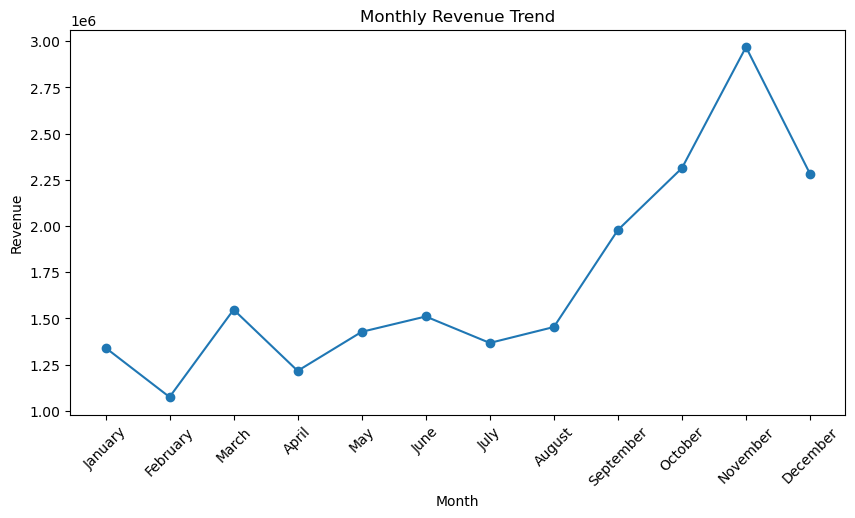

In [10]:
# Monthly Revenue Trend
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Highest Revenue Month
best_month = monthly_sales.loc[
    monthly_sales["Revenue"].idxmax()
]

best_month

Month                  11
Month_Name       November
Revenue       2968159.922
Name: 10, dtype: object

In [12]:
# Daily Scales Pattern
daily_sales = (
    df.groupby("Day_Name")["Revenue"]
    .sum()
    .reset_index()
)

daily_sales

,Day_Name,Revenue
0,Friday,3323908.883
1,Monday,3581594.176
2,Saturday,9803.050
3,Sunday,1799147.282
4,Thursday,4195212.762
5,Tuesday,4078149.962
6,Wednesday,3488444.333


In [14]:
# in day order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


daily_sales["Day_Name"] = pd.Categorical(
    daily_sales["Day_Name"],
    categories=day_order,
    ordered=True
)


daily_sales = daily_sales.sort_values("Day_Name")

daily_sales

,Day_Name,Revenue
1,Monday,3581594.176
5,Tuesday,4078149.962
6,Wednesday,3488444.333
4,Thursday,4195212.762
0,Friday,3323908.883
2,Saturday,9803.050
3,Sunday,1799147.282


In [15]:
# Top Countries by Revenue
country_sales = (
    df.groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_sales.head(10)

,Country,Revenue
40,United Kingdom,1.741020e+07
11,EIRE,6.587673e+05
26,Netherlands,5.540381e+05
15,Germany,4.250197e+05
14,France,3.504561e+05
0,Australia,1.692835e+05
34,Spain,1.083325e+05
36,Switzerland,1.006856e+05
35,Sweden,9.186982e+04
10,Denmark,6.858069e+04


In [17]:
# UK revenue percentage in total revenue
uk_share = (
    country_sales.iloc[0]["Revenue"] /
    country_sales["Revenue"].sum()
) * 100

uk_share

np.float64(85.02624862197688)

In [18]:
# top products generate most revenue
product_sales = (
    df.groupby("Description")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

product_sales.head(10)

,Description,Revenue
2916,Manual,339241.29
3830,REGENCY CAKESTAND 3 TIER,330590.32
1432,DOTCOM POSTAGE,309854.11
5162,WHITE HANGING HEART T-LIGHT HOLDER,260990.22
3187,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3213,PARTY BUNTING,148318.28
2441,JUMBO BAG RED RETROSPOT,148073.47
303,ASSORTED COLOUR BIRD ORNAMENT,129324.49
3606,POSTAGE,125682.42
3180,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29


In [19]:
# top quantity products sell
product_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "Quantity",
        ascending=False
    )
)

product_quantity.head(10)

,Description,Quantity
5283,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139
5162,WHITE HANGING HEART T-LIGHT HOLDER,94658
3187,"PAPER CRAFT , LITTLE BIRDIE",80995
303,ASSORTED COLOUR BIRD ORNAMENT,80082
2749,MEDIUM CERAMIC TOP STORAGE JAR,78033
2441,JUMBO BAG RED RETROSPOT,77699
769,BROCADE RING PURSE,70369
3123,PACK OF 60 PINK PAISLEY CAKE CASES,56061
160,60 TEATIME FAIRY CAKE CASES,54028
4615,SMALL POPCORN HOLDER,48561


In [20]:
# Top customers by revenue
customer_sales = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

customer_sales.head(10)

,Customer ID,Revenue
5692,18102.0,580987.04
2277,14646.0,528602.52
1789,14156.0,313437.62
2538,14911.0,291420.81
5050,17450.0,244784.25
1331,13694.0,195640.69
5109,17511.0,172132.87
4061,16446.0,168472.50
4295,16684.0,147142.77
68,12415.0,144458.37


In [21]:
# Number of orders per customers
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index()
)

customer_orders.columns = [
    "Customer ID",
    "Total Orders"
]

customer_orders.head()

,Customer ID,Total Orders
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


In [22]:
# Combine customer values
# spending + orders = 

customer_analysis = customer_sales.merge(
    customer_orders,
    on="Customer ID"
)

customer_analysis.head()

,Customer ID,Revenue,Total Orders
0,18102.0,580987.04,145
1,14646.0,528602.52,151
2,14156.0,313437.62,156
3,14911.0,291420.81,398
4,17450.0,244784.25,51


In [23]:
# Average Customer Spend
avg_customer_value = (
    customer_analysis["Revenue"].mean()
)

avg_customer_value

np.float64(2955.9040945899965)

In [24]:
# High Value Customers
customer_analysis["Customer Segment"] = np.where(
    customer_analysis["Revenue"] >
    customer_analysis["Revenue"].quantile(0.9),
    "High Value",
    "Regular"
)

In [25]:
customer_analysis["Customer Segment"].value_counts()

Customer Segment
Regular       5290
High Value     588
Name: count, dtype: int64

# Sales Performance Analysis

## Objective
Analyze overall sales performance to identify trends, peak sales periods, and overall business health.

## Business Questions
- How much revenue did the company generate?
- How many orders were placed?
- How many customers purchased?
- What is the average order value?
- Which month generated the highest revenue?

In [26]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        round(average_order_value, 2)
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,20476260.45
1,Total Orders,40079.00
2,Total Customers,5878.00
3,Average Order Value,510.90


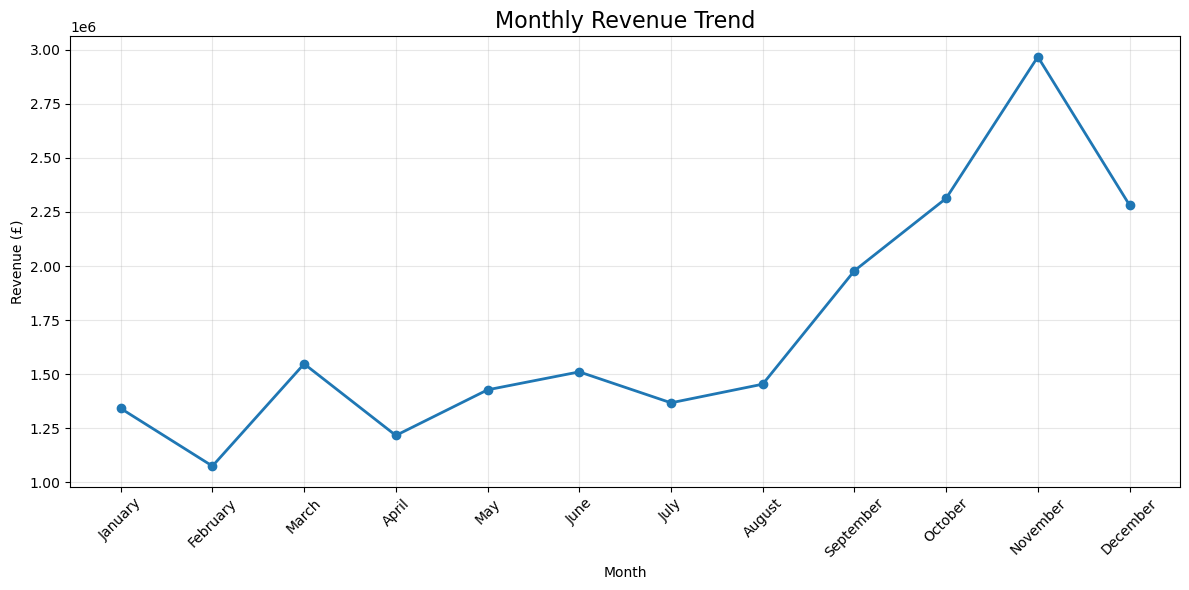

In [27]:
# Monthly revenue trend
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Key Insight

- Revenue steadily increases during the second half of the year.
- November records the highest revenue (~£2.97M).
- The trend suggests strong seasonal demand during the holiday shopping period.

### Recommendation

Increase inventory, marketing budget, and logistics capacity before November to capitalize on peak demand.

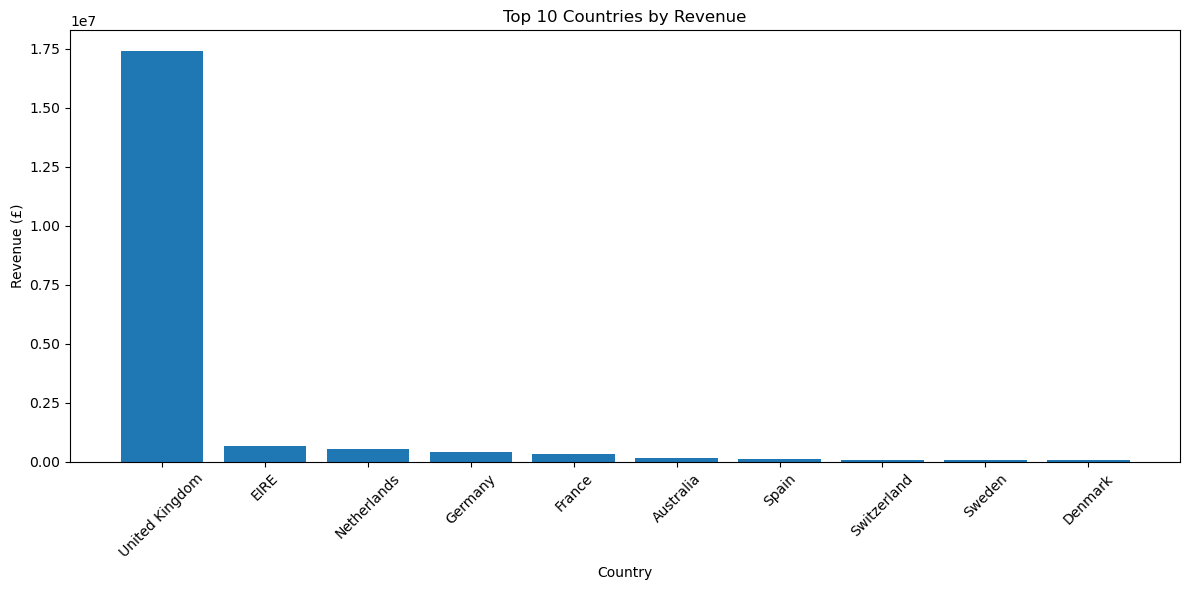

In [30]:
# Country Analysis
top10_country = country_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_country["Country"],
    top10_country["Revenue"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")

plt.tight_layout()

plt.show()

### Key Findings

- United Kingdom contributes the majority of revenue.
- International markets contribute significantly less.
- EIRE, Netherlands, Germany and France are the strongest international markets.

### Recommendation

Expand marketing efforts in the top-performing international countries while maintaining UK market leadership.

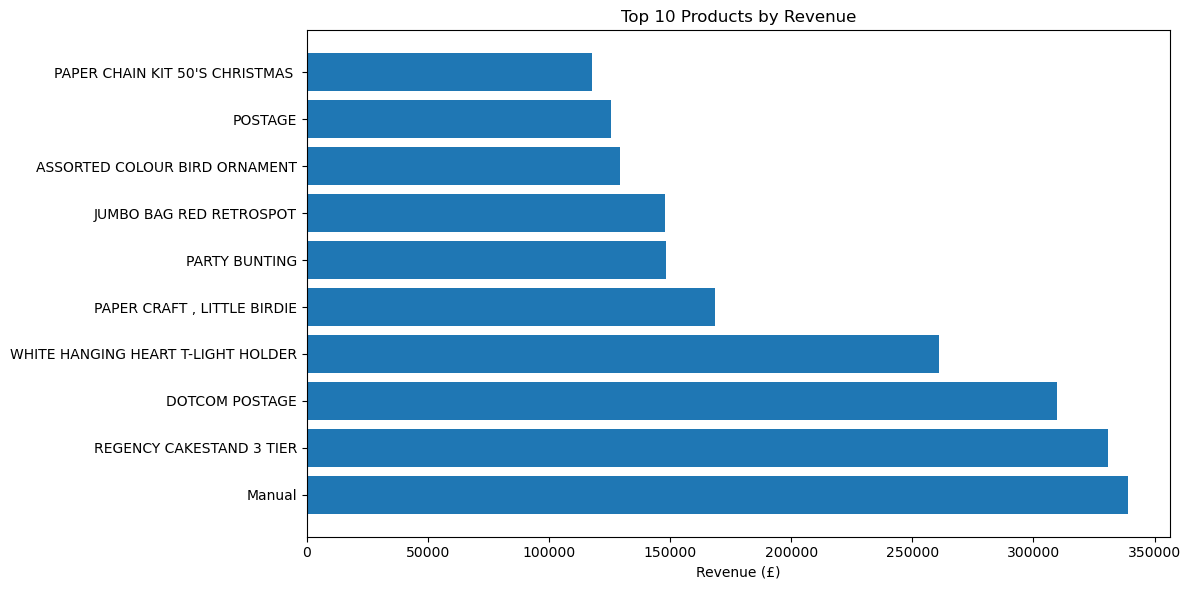

In [29]:
# Product Performance
top_products = product_sales.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_products["Description"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")

plt.tight_layout()

plt.show()

### Business Insight

A small number of products contribute a disproportionately large share of revenue.

### Recommendation

- Ensure sufficient inventory for high-revenue products.
- Bundle these products with slower-moving products.
- Prioritize them in promotional campaigns.

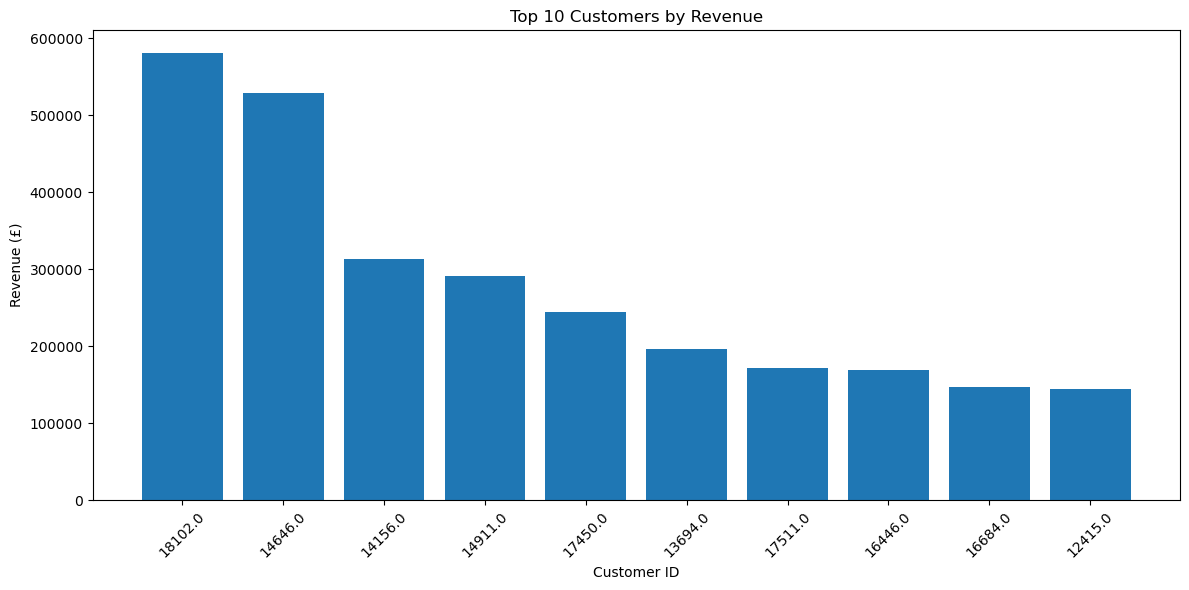

In [31]:
# Customer Analysis
top_customers = customer_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_customers["Customer ID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

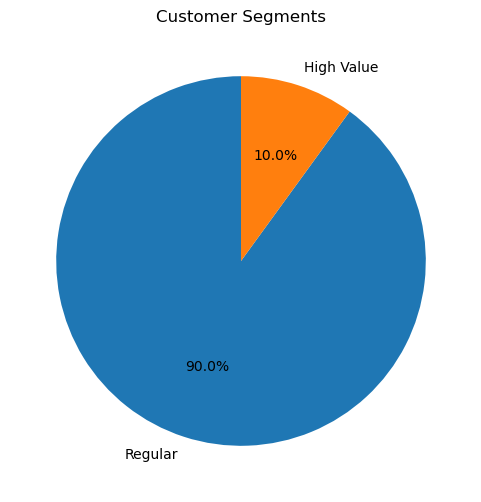

In [32]:
# Customer Segments
segment_counts = customer_analysis["Customer Segment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Segments")

plt.show()

### Key Findings

- Approximately 10% of customers are classified as High Value.
- These customers contribute a significant portion of total revenue.
- Most customers belong to the Regular segment.

### Recommendation

- Develop a loyalty program for High Value customers.
- Offer personalized promotions to encourage Regular customers to increase spending.

# Executive Summary

## Key Findings

- Generated over £20.47M in revenue.
- Processed more than 40,000 orders.
- Served 5,878 unique customers.
- November was the highest revenue month.
- The United Kingdom is the dominant market.
- Revenue is concentrated among a relatively small group of products and customers.

## Business Recommendations

1. Increase inventory before peak sales months.
2. Strengthen customer loyalty programs for High Value customers.
3. Expand marketing in top-performing international markets.
4. Focus promotions on high-performing products.
5. Investigate opportunities to increase repeat purchases from Regular customers.